In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("henrysue/online-shoppers-intention")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-shoppers-intention' dataset.
Path to dataset files: /kaggle/input/online-shoppers-intention


In [8]:
import pandas as pd

df = pd.read_csv(path + "/online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Data Overview and Preprocessing

First, let's get a general understanding of the dataset, including data types and non-null values. This will help us identify any immediate needs for data cleaning or type conversion.

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [10]:
print(df.describe())

       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        7.00000

The `df.info()` output shows that 'Revenue', 'Weekend', and 'VisitorType' are object or boolean types. 'Month' is also an object type. Many features are numerical, but some might need encoding or specific handling. There are no missing values based on the `info` output, as all columns have 12330 non-null entries, matching the total number of entries.

Next, let's check the unique values in the categorical columns to understand their distribution and prepare for encoding.

In [11]:
# Check unique values for categorical columns
print("Unique values for 'Month':", df['Month'].unique())
print("Unique values for 'OperatingSystems':", df['OperatingSystems'].unique())
print("Unique values for 'Browser':", df['Browser'].unique())
print("Unique values for 'Region':", df['Region'].unique())
print("Unique values for 'TrafficType':", df['TrafficType'].unique())
print("Unique values for 'VisitorType':", df['VisitorType'].unique())
print("Unique values for 'Weekend':", df['Weekend'].unique())
print("Unique values for 'Revenue':", df['Revenue'].unique())

Unique values for 'Month': ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
Unique values for 'OperatingSystems': [1 2 4 3 7 6 8 5]
Unique values for 'Browser': [ 1  2  3  4  5  6  7 10  8  9 12 13 11]
Unique values for 'Region': [1 9 2 3 4 5 6 7 8]
Unique values for 'TrafficType': [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20]
Unique values for 'VisitorType': ['Returning_Visitor' 'New_Visitor' 'Other']
Unique values for 'Weekend': [False  True]
Unique values for 'Revenue': [False  True]


### Feature Engineering and Encoding

We need to convert categorical features into numerical ones. 'Month' and 'VisitorType' will be label encoded. 'Weekend' and 'Revenue' are boolean and will be converted to integers (0 and 1).

In [12]:
from sklearn.preprocessing import LabelEncoder

# Encode 'Month'
le = LabelEncoder()
df['Month'] = le.fit_transform(df['Month'])

# Encode 'VisitorType'
df['VisitorType'] = le.fit_transform(df['VisitorType'])

# Convert 'Weekend' and 'Revenue' from boolean to int
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

print("DataFrame after encoding categorical features:")
print(df.head())
print("\nUpdated DataFrame Info:")
print(df.info())

DataFrame after encoding categorical features:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0      2                 1   
1        

### Outlier Detection and Visualization (Numerical Features)

Before scaling, it's good practice to inspect numerical features for outliers that might skew our models. We'll use box plots for a quick visual check on some of the key duration and rate-related features.

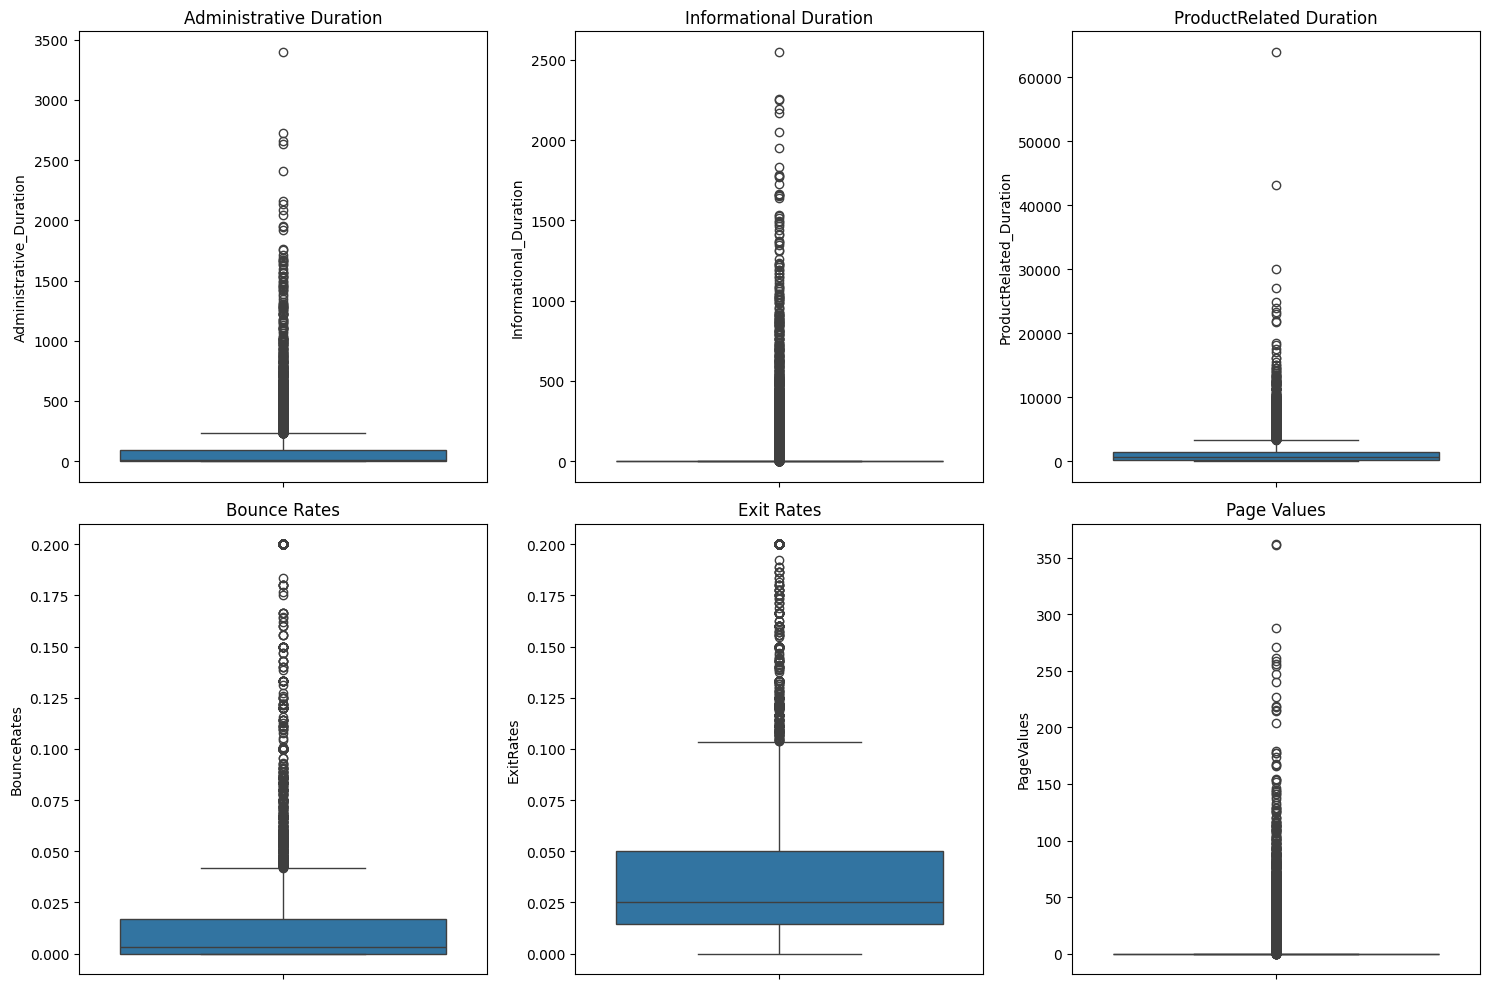

In [13]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.boxplot(y=df['Administrative_Duration'])
plt.title('Administrative Duration')

plt.subplot(2, 3, 2)
sns.boxplot(y=df['Informational_Duration'])
plt.title('Informational Duration')

plt.subplot(2, 3, 3)
sns.boxplot(y=df['ProductRelated_Duration'])
plt.title('ProductRelated Duration')

plt.subplot(2, 3, 4)
sns.boxplot(y=df['BounceRates'])
plt.title('Bounce Rates')

plt.subplot(2, 3, 5)
sns.boxplot(y=df['ExitRates'])
plt.title('Exit Rates')

plt.subplot(2, 3, 6)
sns.boxplot(y=df['PageValues'])
plt.title('Page Values')

plt.tight_layout()
plt.show()

### Handling Outliers (Capping using IQR)

From the box plots, it's clear there are significant outliers in several duration and value-related features. To handle these, we will cap the outliers using the Interquartile Range (IQR) method. Values below `Q1 - 1.5 * IQR` will be set to `Q1 - 1.5 * IQR`, and values above `Q3 + 1.5 * IQR` will be set to `Q3 + 1.5 * IQR`.

In [14]:
for col in ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("DataFrame after capping outliers:")
print(df.describe())

DataFrame after capping outliers:
       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                56.972776       0.503569   
std          3.321784                79.250727       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000               233.140625      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count                 12330.0    12330.000000             12330.000000   
mean                      0.0       31.731468               989.691454   
std                       0.0       44.475503              1033.120180   
min                       0.0        0.000000                 0.000000   
25%       

### Feature Scaling (Standard Scaling)

Now, we will apply Standard Scaling to all numerical features. This will standardize our data, making the features have a mean of 0 and a standard deviation of 1, which is beneficial for many machine learning algorithms.

In [15]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (excluding the target 'Revenue')
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('Revenue')

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("DataFrame after Standard Scaling:")
print(df.head())
print("\nDescriptive statistics after scaling:")
print(df[numerical_cols].describe())

DataFrame after Standard Scaling:
   Administrative  Administrative_Duration  Informational  \
0       -0.696993                -0.718922      -0.396478   
1       -0.696993                -0.718922      -0.396478   
2       -0.696993                -0.718922      -0.396478   
3       -0.696993                -0.718922      -0.396478   
4       -0.696993                -0.718922      -0.396478   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0       -0.691003                -0.958002   
1                     0.0       -0.668518                -0.896052   
2                     0.0       -0.691003                -0.958002   
3                     0.0       -0.668518                -0.955421   
4                     0.0       -0.488636                -0.350594   

   BounceRates  ExitRates  PageValues  SpecialDay     Month  OperatingSystems  \
0     2.090999   2.199769         0.0   -0.308821 -1.334959         -1.233426   
1    -0.734733  

### Data Splitting

Finally, we will split our preprocessed data into training and testing sets. The 'Revenue' column will be our target variable (y), and the remaining features will be our input features (X).

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('Revenue', axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of Revenue in training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of Revenue in test set:")
print(y_test.value_counts(normalize=True))

X_train shape: (9864, 17)
X_test shape: (2466, 17)
y_train shape: (9864,)
y_test shape: (2466,)

Distribution of Revenue in training set:
Revenue
0    0.845296
1    0.154704
Name: proportion, dtype: float64

Distribution of Revenue in test set:
Revenue
0    0.845093
1    0.154907
Name: proportion, dtype: float64


## Model Training and Evaluation

Now that the data is preprocessed and split, we will train and evaluate the requested machine learning models. We will start by defining a utility function to evaluate classification models, which will help us compare their performance consistently.

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 'N/A'
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    return accuracy, precision, recall, f1, roc_auc

### K-Nearest Neighbors (KNN)

Let's start by training a K-Nearest Neighbors classifier. We will use a default `n_neighbors` value for now and consider hyperparameter tuning later if needed.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

print("KNN Model Evaluation:")
k_accuracy, k_precision, k_recall, k_f1, k_roc_auc = evaluate_model(knn_model, X_test, y_test)

KNN Model Evaluation:
Accuracy: 0.8305
Precision: 0.3846
Recall: 0.1571
F1-Score: 0.2230
ROC AUC Score: 0.6647
Confusion Matrix:
[[1988   96]
 [ 322   60]]


### Naive Bayes (GaussianNB)

Next, let's train a Gaussian Naive Bayes classifier. This model assumes that the features follow a Gaussian distribution and are conditionally independent given the class.

In [19]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes Model Evaluation:")
nb_accuracy, nb_precision, nb_recall, nb_f1, nb_roc_auc = evaluate_model(nb_model, X_test, y_test)

Naive Bayes Model Evaluation:
Accuracy: 0.6906
Precision: 0.2604
Recall: 0.5419
F1-Score: 0.3517
ROC AUC Score: 0.6900
Confusion Matrix:
[[1496  588]
 [ 175  207]]


### Decision Tree Classifier

Now, let's train a Decision Tree classifier. Decision trees are non-parametric supervised learning methods used for classification and regression. We'll start with a default tree and later consider hyperparameter tuning.

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree Model Evaluation:")
dt_accuracy, dt_precision, dt_recall, dt_f1, dt_roc_auc = evaluate_model(dt_model, X_test, y_test)

Decision Tree Model Evaluation:
Accuracy: 0.7685
Precision: 0.2723
Recall: 0.2958
F1-Score: 0.2836
ROC AUC Score: 0.5754
Confusion Matrix:
[[1782  302]
 [ 269  113]]


### Random Forest Classifier

Finally, let's train a Random Forest classifier. Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Model Evaluation:")
rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc = evaluate_model(rf_model, X_test, y_test)

Random Forest Model Evaluation:
Accuracy: 0.8451
Precision: 0.5000
Recall: 0.1099
F1-Score: 0.1803
ROC AUC Score: 0.7384
Confusion Matrix:
[[2042   42]
 [ 340   42]]


## Model Comparison and Summary

Let's compile the results from all trained models to compare their performance.

In [22]:
results = pd.DataFrame({
    'Model': ['KNN', 'Naive Bayes', 'Decision Tree', 'Random Forest'],
    'Accuracy': [k_accuracy, nb_accuracy, dt_accuracy, rf_accuracy],
    'Precision': [k_precision, nb_precision, dt_precision, rf_precision],
    'Recall': [k_recall, nb_recall, dt_recall, rf_recall],
    'F1-Score': [k_f1, nb_f1, dt_f1, rf_f1],
    'ROC AUC': [k_roc_auc, nb_roc_auc, dt_roc_auc, rf_roc_auc]
})

print(results.sort_values(by='F1-Score', ascending=False))

           Model  Accuracy  Precision    Recall  F1-Score   ROC AUC
1    Naive Bayes  0.690592   0.260377  0.541885  0.351742  0.689953
2  Decision Tree  0.768451   0.272289  0.295812  0.283563  0.575449
0            KNN  0.830495   0.384615  0.157068  0.223048  0.664740
3  Random Forest  0.845093   0.500000  0.109948  0.180258  0.738374


### Naive Bayes (GaussianNB)

Next, let's train a Gaussian Naive Bayes classifier. This model assumes that the features follow a Gaussian distribution and are conditionally independent given the class.

In [23]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes Model Evaluation:")
nb_accuracy, nb_precision, nb_recall, nb_f1, nb_roc_auc = evaluate_model(nb_model, X_test, y_test)

Naive Bayes Model Evaluation:
Accuracy: 0.6906
Precision: 0.2604
Recall: 0.5419
F1-Score: 0.3517
ROC AUC Score: 0.6900
Confusion Matrix:
[[1496  588]
 [ 175  207]]


### Decision Tree Classifier

Now, let's train a Decision Tree classifier. Decision trees are non-parametric supervised learning methods used for classification and regression. We'll start with a default tree and later consider hyperparameter tuning.

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree Model Evaluation:")
dt_accuracy, dt_precision, dt_recall, dt_f1, dt_roc_auc = evaluate_model(dt_model, X_test, y_test)

Decision Tree Model Evaluation:
Accuracy: 0.7685
Precision: 0.2723
Recall: 0.2958
F1-Score: 0.2836
ROC AUC Score: 0.5754
Confusion Matrix:
[[1782  302]
 [ 269  113]]


### Random Forest Classifier

Finally, let's train a Random Forest classifier. Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Model Evaluation:")
rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc = evaluate_model(rf_model, X_test, y_test)

Random Forest Model Evaluation:
Accuracy: 0.8451
Precision: 0.5000
Recall: 0.1099
F1-Score: 0.1803
ROC AUC Score: 0.7384
Confusion Matrix:
[[2042   42]
 [ 340   42]]


## Model Comparison and Summary

Let's compile the results from all trained models to compare their performance.

In [26]:
results = pd.DataFrame({
    'Model': ['KNN', 'Naive Bayes', 'Decision Tree', 'Random Forest'],
    'Accuracy': [k_accuracy, nb_accuracy, dt_accuracy, rf_accuracy],
    'Precision': [k_precision, nb_precision, dt_precision, rf_precision],
    'Recall': [k_recall, nb_recall, dt_recall, rf_recall],
    'F1-Score': [k_f1, nb_f1, dt_f1, rf_f1],
    'ROC AUC': [k_roc_auc, nb_roc_auc, dt_roc_auc, rf_roc_auc]
})

print(results.sort_values(by='F1-Score', ascending=False))

           Model  Accuracy  Precision    Recall  F1-Score   ROC AUC
1    Naive Bayes  0.690592   0.260377  0.541885  0.351742  0.689953
2  Decision Tree  0.768451   0.272289  0.295812  0.283563  0.575449
0            KNN  0.830495   0.384615  0.157068  0.223048  0.664740
3  Random Forest  0.845093   0.500000  0.109948  0.180258  0.738374


## Hyperparameter Tuning

Now, let's perform hyperparameter tuning to further optimize the performance of our models, focusing on the Random Forest Classifier as it generally benefits significantly from tuning.

### Random Forest Classifier - Hyperparameter Tuning with GridSearchCV

We will use `GridSearchCV` to systematically work through multiple combinations of parameter values to find the best ones. Given computational constraints, we'll select a reasonable range of parameters for `n_estimators`, `max_depth`, and `min_samples_split`.

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                            param_grid=param_grid_rf,
                            cv=3,
                            scoring='f1',
                            n_jobs=-1,
                            verbose=1)

rf_grid_search.fit(X_train, y_train)

print("Best parameters for Random Forest:", rf_grid_search.best_params_)
print("Best F1-Score for Random Forest (Cross-validation):", rf_grid_search.best_score_)

best_rf_model = rf_grid_search.best_estimator_

print("\nOptimized Random Forest Model Evaluation on Test Set:")
rf_tuned_accuracy, rf_tuned_precision, rf_tuned_recall, rf_tuned_f1, rf_tuned_roc_auc = evaluate_model(best_rf_model, X_test, y_test)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best F1-Score for Random Forest (Cross-validation): 0.17082607748549147

Optimized Random Forest Model Evaluation on Test Set:
Accuracy: 0.8414
Precision: 0.4483
Recall: 0.1021
F1-Score: 0.1663
ROC AUC Score: 0.7301
Confusion Matrix:
[[2036   48]
 [ 343   39]]


### Optimized Random Forest Model Performance

After hyperparameter tuning, let's update our comparison table with the performance of the best Random Forest model found by `GridSearchCV`.

In [28]:
results_tuned = pd.DataFrame({
    'Model': ['KNN', 'Naive Bayes', 'Decision Tree', 'Random Forest (Original)', 'Random Forest (Tuned)'],
    'Accuracy': [k_accuracy, nb_accuracy, dt_accuracy, rf_accuracy, rf_tuned_accuracy],
    'Precision': [k_precision, nb_precision, dt_precision, rf_precision, rf_tuned_precision],
    'Recall': [k_recall, nb_recall, dt_recall, rf_recall, rf_tuned_recall],
    'F1-Score': [k_f1, nb_f1, dt_f1, rf_f1, rf_tuned_f1],
    'ROC AUC': [k_roc_auc, nb_roc_auc, dt_roc_auc, rf_roc_auc, rf_tuned_roc_auc]
})

print("Model Comparison (Including Tuned Random Forest):")
print(results_tuned.sort_values(by='F1-Score', ascending=False))

Model Comparison (Including Tuned Random Forest):
                      Model  Accuracy  Precision    Recall  F1-Score   ROC AUC
1               Naive Bayes  0.690592   0.260377  0.541885  0.351742  0.689953
2             Decision Tree  0.768451   0.272289  0.295812  0.283563  0.575449
0                       KNN  0.830495   0.384615  0.157068  0.223048  0.664740
3  Random Forest (Original)  0.845093   0.500000  0.109948  0.180258  0.738374
4     Random Forest (Tuned)  0.841444   0.448276  0.102094  0.166311  0.730064


### Decision Tree Classifier - Hyperparameter Tuning with GridSearchCV

Let's tune the Decision Tree Classifier to find optimal parameters for `max_depth` and `min_samples_split` to improve its performance.

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

dt_grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                            param_grid=param_grid_dt,
                            cv=3,
                            scoring='f1',
                            n_jobs=-1,
                            verbose=1)

dt_grid_search.fit(X_train, y_train)

print("Best parameters for Decision Tree:", dt_grid_search.best_params_)
print("Best F1-Score for Decision Tree (Cross-validation):", dt_grid_search.best_score_)

best_dt_model = dt_grid_search.best_estimator_

print("\nOptimized Decision Tree Model Evaluation on Test Set:")
dt_tuned_accuracy, dt_tuned_precision, dt_tuned_recall, dt_tuned_f1, dt_tuned_roc_auc = evaluate_model(best_dt_model, X_test, y_test)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best F1-Score for Decision Tree (Cross-validation): 0.29887661503548707

Optimized Decision Tree Model Evaluation on Test Set:
Accuracy: 0.7689
Precision: 0.2718
Recall: 0.2932
F1-Score: 0.2821
ROC AUC Score: 0.5746
Confusion Matrix:
[[1784  300]
 [ 270  112]]


### Updated Model Comparison (Including Tuned Decision Tree)

Let's see how the tuned Decision Tree model compares to the others.

In [30]:
results_final = pd.DataFrame({
    'Model': ['KNN', 'Naive Bayes', 'Decision Tree (Original)', 'Random Forest (Original)', 'Random Forest (Tuned)', 'Decision Tree (Tuned)'],
    'Accuracy': [k_accuracy, nb_accuracy, dt_accuracy, rf_accuracy, rf_tuned_accuracy, dt_tuned_accuracy],
    'Precision': [k_precision, nb_precision, dt_precision, rf_precision, rf_tuned_precision, dt_tuned_precision],
    'Recall': [k_recall, nb_recall, dt_recall, rf_recall, rf_tuned_recall, dt_tuned_recall],
    'F1-Score': [k_f1, nb_f1, dt_f1, rf_f1, rf_tuned_f1, dt_tuned_f1],
    'ROC AUC': [k_roc_auc, nb_roc_auc, dt_roc_auc, rf_roc_auc, rf_tuned_roc_auc, dt_tuned_roc_auc]
})

print("Final Model Comparison:")
print(results_final.sort_values(by='F1-Score', ascending=False))

Final Model Comparison:
                      Model  Accuracy  Precision    Recall  F1-Score   ROC AUC
1               Naive Bayes  0.690592   0.260377  0.541885  0.351742  0.689953
2  Decision Tree (Original)  0.768451   0.272289  0.295812  0.283563  0.575449
5     Decision Tree (Tuned)  0.768856   0.271845  0.293194  0.282116  0.574620
0                       KNN  0.830495   0.384615  0.157068  0.223048  0.664740
3  Random Forest (Original)  0.845093   0.500000  0.109948  0.180258  0.738374
4     Random Forest (Tuned)  0.841444   0.448276  0.102094  0.166311  0.730064


### Visualize ROC Curves for All Models

Let's visualize the Receiver Operating Characteristic (ROC) curves for all the trained models to compare their performance, especially in distinguishing between the positive and negative classes. The Area Under the Curve (AUC) provides a single metric to summarize the performance of the classifier across all possible classification thresholds.

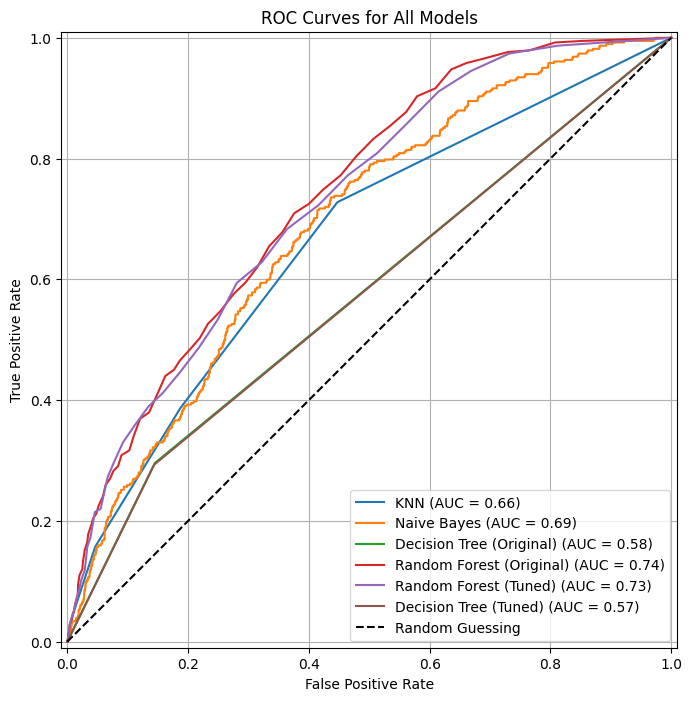

In [31]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Create a dictionary of models to iterate through
models = {
    'KNN': knn_model,
    'Naive Bayes': nb_model,
    'Decision Tree (Original)': dt_model,
    'Random Forest (Original)': rf_model,
    'Random Forest (Tuned)': best_rf_model,
    'Decision Tree (Tuned)': best_dt_model
}

plt.figure(figsize=(10, 8))

# Plot ROC curve for each model
for name, model in models.items():
    # Check if the model has predict_proba, otherwise skip or handle appropriately
    if hasattr(model, 'predict_proba'):
        RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())
    else:
        print(f"Skipping {name}: Does not have predict_proba method.")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


### Cross-validation for Naive Bayes Model

To further confirm the stability and generalization ability of the Naive Bayes model, which had the highest F1-Score, we will perform k-fold cross-validation. This technique provides a more reliable estimate of model performance by training and evaluating the model on different subsets of the data.

In [32]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the Naive Bayes model
cv_scores = cross_val_score(nb_model, X, y, cv=5, scoring='accuracy')

print("Naive Bayes Cross-validation Accuracy Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")


Naive Bayes Cross-validation Accuracy Scores: [0.74128143 0.75993512 0.67883212 0.6431468  0.65044607]
Mean CV Accuracy: 0.6947
Standard Deviation of CV Accuracy: 0.0475


## Exploratory Data Analysis (EDA)

Let's perform some additional EDA to better understand the dataset, its distributions, and relationships between features, especially with the target variable `Revenue`.

### 1. Target Variable Distribution

First, let's look at the distribution of our target variable, `Revenue`, to understand the class balance.

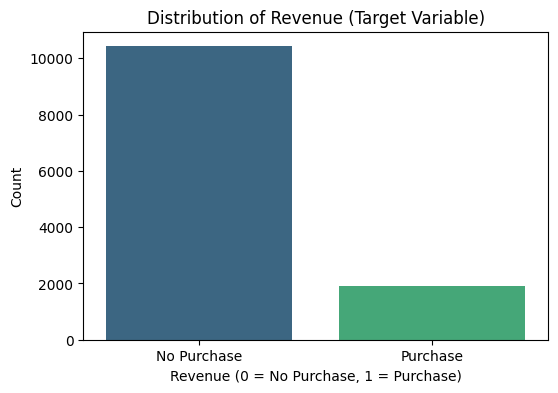

Revenue Distribution:
Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64


In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, palette='viridis')
plt.title('Distribution of Revenue (Target Variable)')
plt.xlabel('Revenue (0 = No Purchase, 1 = Purchase)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Purchase', 'Purchase'])
plt.show()

print("Revenue Distribution:")
print(df['Revenue'].value_counts(normalize=True))


### 2. Correlation Matrix

A correlation matrix can help us identify linear relationships between features and the target variable. Since our features are already scaled, we can directly compute and visualize the correlations.

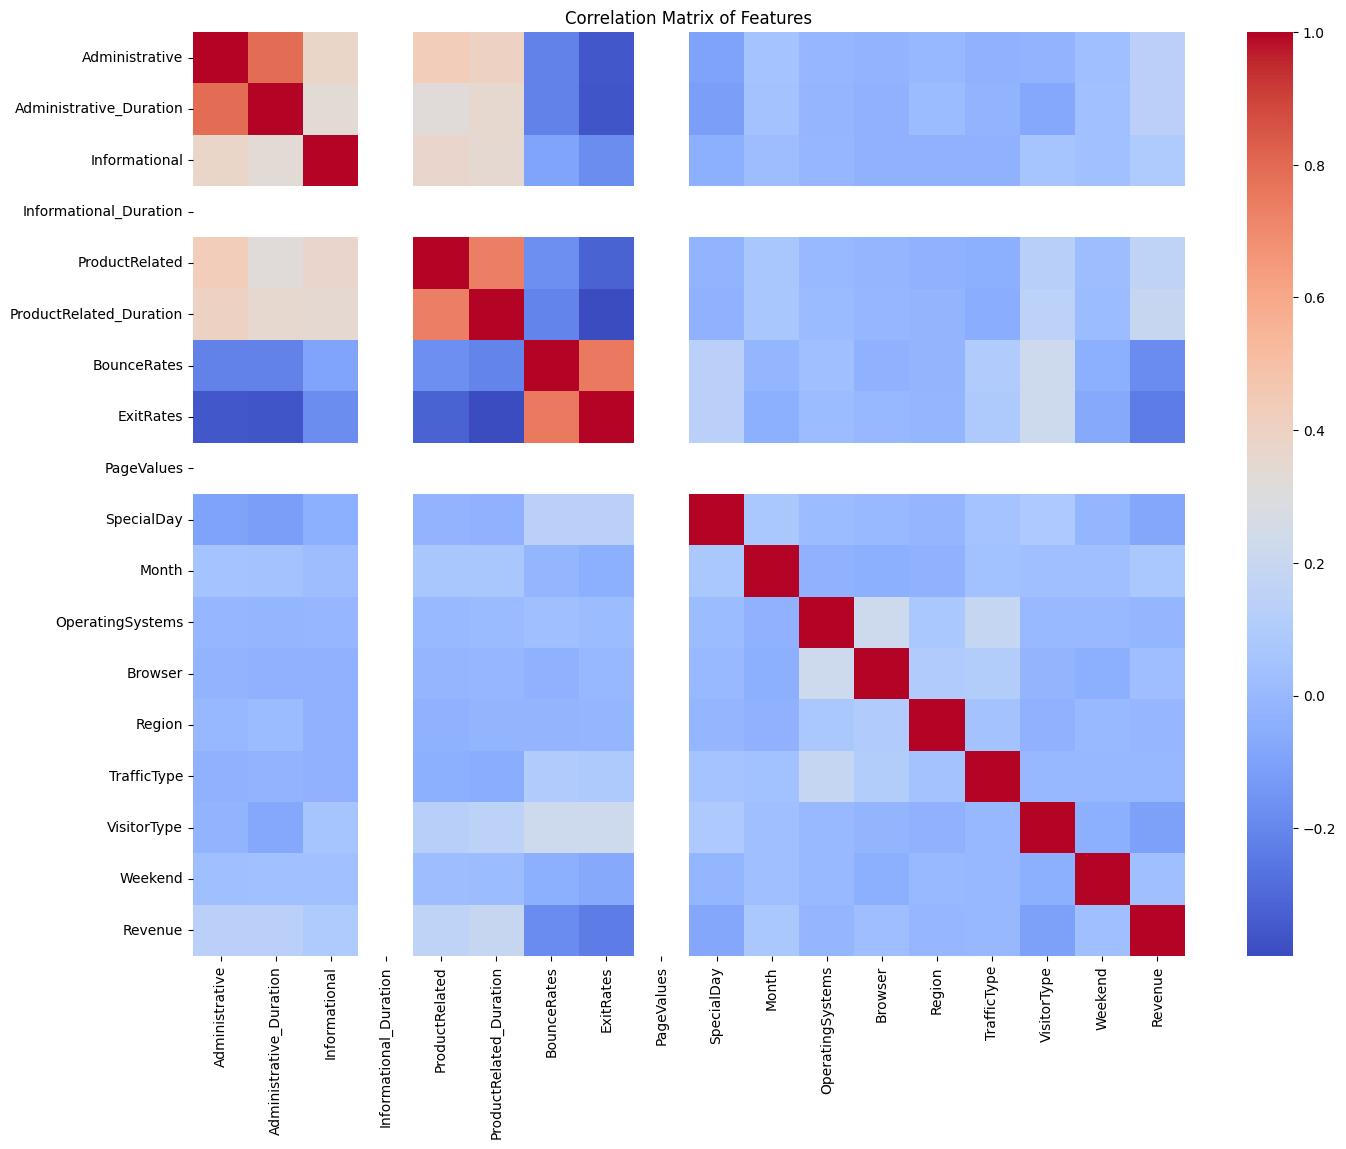

In [34]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


### 3. Feature Distributions

Let's visualize the distributions of some key numerical features to see their patterns after scaling and outlier treatment. We'll also look at a few categorical features to see their frequency distributions.

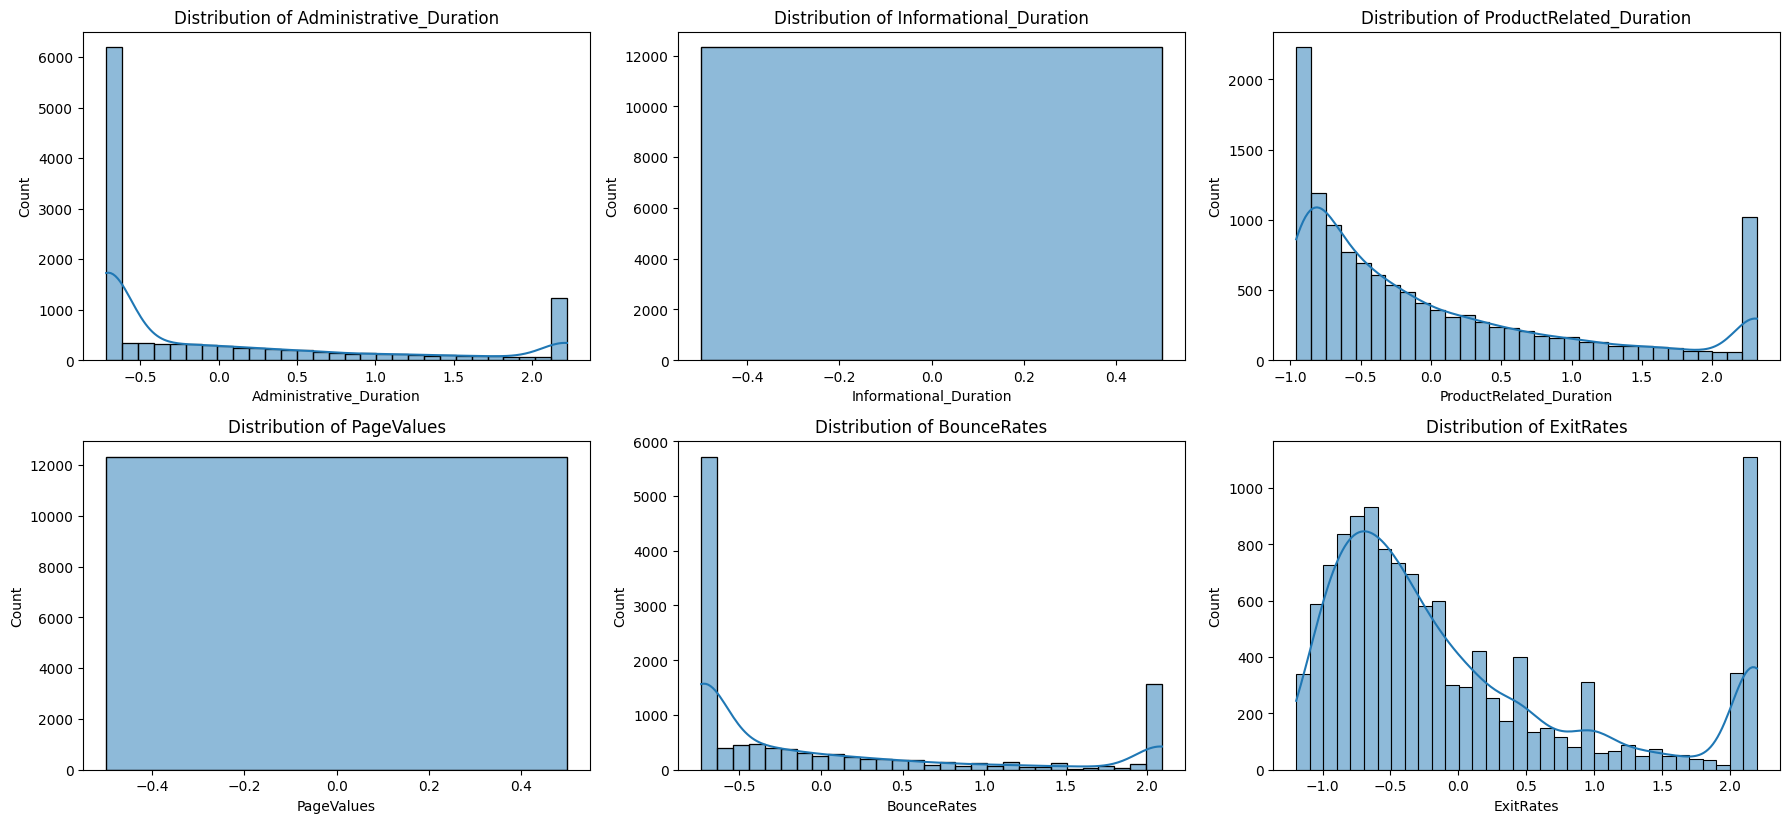

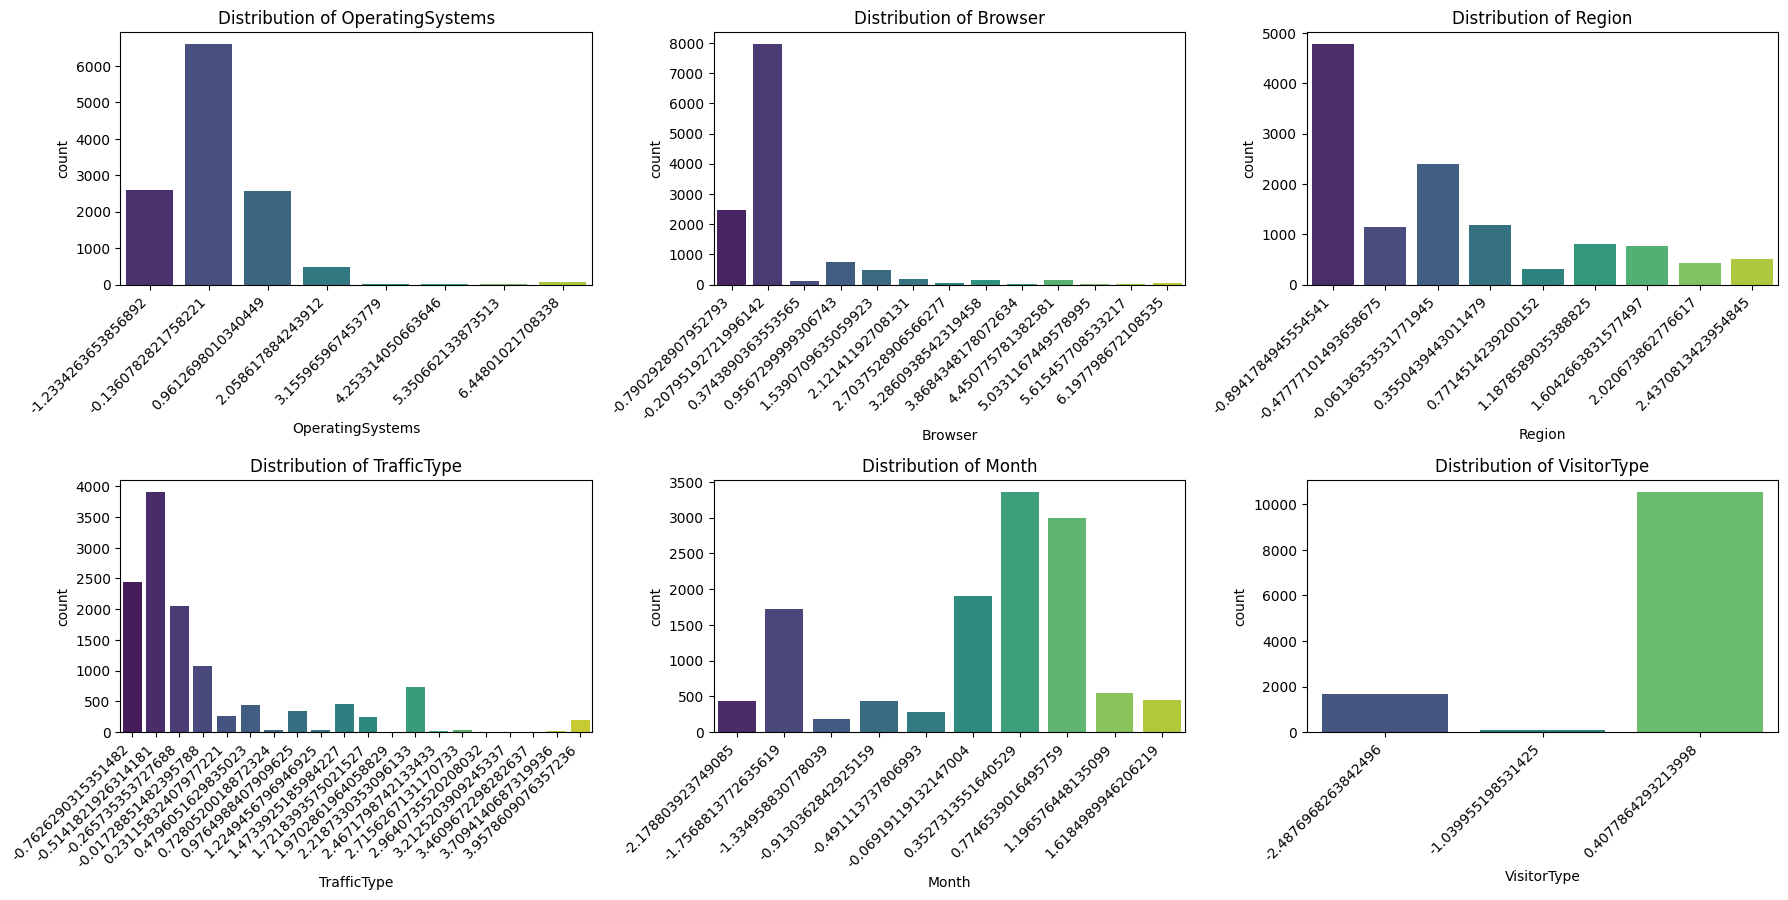

In [35]:
numerical_features = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'PageValues', 'BounceRates', 'ExitRates']
categorical_features = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Month', 'VisitorType']

# Histograms for numerical features
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Countplots for categorical features
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(x=col, data=df, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
